In [2]:
import pandas as pd 
import numpy as np 
import sklearn as sk 

In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [ ]:
feature_vars = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                'Population', 'AveOccup', 'Latitude', 'Longitude']
x = pd.DataFrame(housing.data, columns=housing.feature_names) 
y = pd.Series(housing.target, name='med_house_value')
print(x.head(5))
print('X Value Summary Statistics')
print(x.agg(['mean', 'median', 'max', 'std']))
print('Y Value Summary Statistics')
print(y.agg(['mean', 'median', 'max', 'std']))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
X Value Summary Statistics
           MedInc   HouseAge    AveRooms  AveBedrms    Population  \
mean     3.870671  28.639486    5.429000   1.096675   1425.476744   
median   3.534800  29.000000    5.229129   1.048780   1166.000000   
max     15.000100  52.000000  141.909091  34.066667  35682.000000   
std      1.899822  12.585558    2.474173   0.473911   1132.462122   

           AveOccup   Latitude   Longitude  
mean       3.070655  35.631861 -119

<bound method Series.max of 0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: med_house_value, Length: 20640, dtype: float64>

<Axes: >

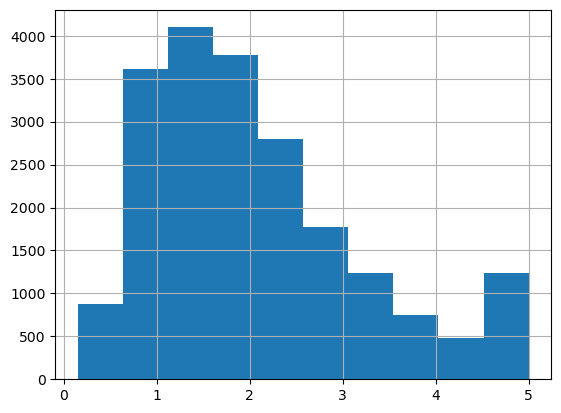

In [14]:
y.hist()

In [19]:
y.sort_values()

9188     0.14999
19802    0.14999
2799     0.14999
2521     0.14999
5887     0.17500
          ...   
16938    5.00001
16936    5.00001
16935    5.00001
8291     5.00001
18055    5.00001
Name: med_house_value, Length: 20640, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

print(lin_reg.coef_)

y_pred = lin_reg.predict(x_test)

print(y_test)
print(y_pred)

[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: med_house_value, Length: 4128, dtype: float64
[0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]


In [6]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Unscaled Data Model:")
print(f"Mean Squared Error: {mse:}")
print(f"Root Squared Error: {rmse:}")
print(f"R² Score: {r2:}")

Unscaled Data Model:
Mean Squared Error: 0.5558915986952433
Root Squared Error: 0.7455813830127757
R² Score: 0.5757877060324517


What does the R² score tell us about model performance?

The R^2 score indicates the accuracy of a model on a scale of 0 to 1. The R^2 score of 0.575 tells us that the features presents are roughly 57% responsible for the models outputs. This means the model has room for improvement, though it is already fairly decent. Exploring more features would be a worthwhile option to improve the accuracy of the model.  

Which features seem to have the strongest impact on predictions based on the model’s coefficients?

Median Income and Longitude/Latitude have the largest coefficients, though these seem to have a limited effect on the outcome of the model. This makes sense, as the income of the buyer and the location of the house are likely to determine housing prices. This is especially true in California, where homes that are one valley a part can have a price disparity in the millions. 

How well do the predicted values match the actual values?

The predicted values occasionally match the actual values, but there is significant room for improvement in the models capabilities. The features seem to only be telling half of the story. By exploring new features, there is a possibility to improve the match between the predicted values and the actual values. 

In [7]:
from sklearn.preprocessing import StandardScaler

three_vars = ['MedInc', 'HouseAge', 'AveOccup']
z = x[three_vars]
y = pd.Series(housing.target, name='med_house_value')

scaler = StandardScaler()
z_scaled = scaler.fit_transform(z)
y_scaled = pd.DataFrame(z_scaled, columns=z.columns)

print(z.head(5))
print('X Value Summary Statistics')
print(z.agg(['mean', 'median', 'max', 'std']))
print('Y Value Summary Statistics')
print(y.agg(['mean', 'median', 'max', 'std']))

   MedInc  HouseAge  AveOccup
0  8.3252      41.0  2.555556
1  8.3014      21.0  2.109842
2  7.2574      52.0  2.802260
3  5.6431      52.0  2.547945
4  3.8462      52.0  2.181467
X Value Summary Statistics
           MedInc   HouseAge     AveOccup
mean     3.870671  28.639486     3.070655
median   3.534800  29.000000     2.818116
max     15.000100  52.000000  1243.333333
std      1.899822  12.585558    10.386050
Y Value Summary Statistics
mean      2.068558
median    1.797000
max       5.000010
std       1.153956
Name: med_house_value, dtype: float64


In [8]:
lin_reg_scaled = LinearRegression()
z_train_scaled, z_test_scaled, y_train_scaled, y_test_scaled = train_test_split(z_scaled, y, test_size=0.2, random_state=42)
lin_reg_scaled.fit(z_train_scaled, y_train_scaled)
y_pred_scaled = lin_reg_scaled.predict(z_test_scaled)
mse_scaled = mean_squared_error(y_test_scaled, y_pred_scaled)
print(mse_scaled)

0.6615533924375526


In [9]:
mse_scaled = mean_squared_error(y_test_scaled, y_pred_scaled)
rmse_scaled = root_mean_squared_error(y_test_scaled, y_pred_scaled)
r2_scaled = r2_score(y_test_scaled, y_pred_scaled)

print("Scaled Data Model:")
print(f"Mean Squared Error: {mse_scaled}")
print(f"Root Squared Error: {rmse_scaled}")
print(f"R² Score: {r2_scaled}")

Scaled Data Model:
Mean Squared Error: 0.6615533924375526
Root Squared Error: 0.8133593255367229
R² Score: 0.49515502150662494


How does the simplified model compare to the full model?

The simplified model is fairly similar in its inaccuracy, with a 0.495 R^2 score. Meanwhile, the root means squared error (RMSE) is 0.81, compared to the 0.77 of the unscaled model. This means that the model has a larger magnititude between the test data and predictions. 

Would you use this simplified model in practice? Why or why not?

I would not use this simplified model in practice because it has higher variance compared to the unscaled model, and the features presents are a more rudimentary version of the unscaled model. 
